🎉 App Initialization Success: Clean data pulled from MySQL and model trained!


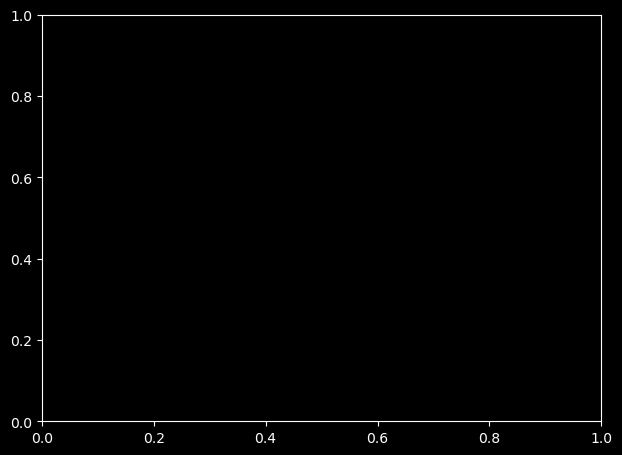

In [37]:
import mysql.connector
import pandas as pd
import customtkinter as ctk
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import warnings as w
w.filterwarnings("ignore")

# 1. DATABASE FETCH & LOCAL TRAINING (Self-contained in this file)
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="energy_logistics_db"
)
# Extract rows directly from your database using a SQL JOIN query
query = """
SELECT t.Commodity_Type, s.Location_Type, s.Regional_Tier, t.Volume_Sold_Liters
FROM Supply_Transactions t
INNER JOIN Distribution_Centers s ON t.Station_ID = s.Center_ID;
"""
df = pd.read_sql(query, conn)
conn.close()

# Dictionaries to map the text labels into numbers for the model
commodity_map = {'Petrol': 1, 'Diesel': 2, 'CNG': 3}
loc_map = {'Rural': 1, 'Urban': 2, 'Highway': 3}
tier_map = {'Tier-3': 1, 'Tier-2': 2, 'Tier-1': 3}

df['Commodity_Num'] = df['Commodity_Type'].map(commodity_map)
df['Loc_Num'] = df['Location_Type'].map(loc_map)
df['Tier_Num'] = df['Regional_Tier'].map(tier_map)

# Split features (Inputs) and target (Output)
X = df[['Commodity_Num', 'Loc_Num', 'Tier_Num']]
y = df['Volume_Sold_Liters']

# Train the model instantly inside the memory of this specific app file
local_knn_model = KNeighborsRegressor(n_neighbors=1)
local_knn_model.fit(X, y)
print("🎉 App Initialization Success: Clean data pulled from MySQL and model trained!")

# 2. THE INTERACTIVE VISUAL DASHBOARD GUI ENGINE
ctk.set_appearance_mode("Dark")
class EnergyDashboardNoPickle(ctk.CTk):
    def __init__(self):
        super().__init__()
        self.title("Executive Supply Dashboard")
        self.geometry("800x450") 

        # --- NOTICE: ALL THESE LINES ARE INDENTED (SHIFTED RIGHT) NOW ---
        # Left Control Pane
        self.left_frame = ctk.CTkFrame(self, width=300)
        self.left_frame.pack(side="left", fill="y", padx=10, pady=10)

        ctk.CTkLabel(self.left_frame, text="Logistics Control Panel", font=("Arial", 16, "bold"), text_color="cyan").pack(pady=10)
                
        self.commodity_dropdown = ctk.CTkComboBox(self.left_frame, values=["Petrol", "Diesel", "CNG"])
        self.commodity_dropdown.pack(pady=10)
        self.loc_dropdown = ctk.CTkComboBox(self.left_frame, values=["Rural", "Urban", "Highway"])
        self.loc_dropdown.pack(pady=10)
        self.tier_dropdown = ctk.CTkComboBox(self.left_frame, values=["Tier-3", "Tier-2", "Tier-1"])
        self.tier_dropdown.pack(pady=10)

        self.btn = ctk.CTkButton(self.left_frame, text="Update Analytics Graph", command=self.draw_analytics)
        self.btn.pack(pady=15)

        # Right Graph Canvas Frame
        self.right_frame = ctk.CTkFrame(self)
        self.right_frame.pack(side="right", fill="both", expand=True, padx=10, pady=10)

        # Create basic background Matplotlib figure setup
        plt.style.use('dark_background')
        self.fig, self.ax = plt.subplots(figsize=(4, 3))
        
        # Bridge the Matplotlib figure canvas inside our right frame panel
        self.canvas = FigureCanvasTkAgg(self.fig, master=self.right_frame)
        self.canvas.get_tk_widget().pack(fill="both", expand=True, padx=5, pady=5)

    def draw_analytics(self):
        # Gather text choices from dropdowns
        commodity = self.commodity_dropdown.get()
        loc = self.loc_dropdown.get()
        tier = self.tier_dropdown.get()

        # Convert the dropdown selections to the input format the model expects
        pred_input = [[commodity_map[commodity], loc_map[loc], tier_map[tier]]]
        
        # Calculate prediction using the model we just trained upstairs in memory
        base_prediction = int(local_knn_model.predict(pred_input))

        # Clear old chart drawing paths before adding new columns
        self.ax.clear()
        
        # Plot comparative data bars side-by-side
        categories = ['Safety Stock Buffer', 'Predicted Demand']
        values = [1200, base_prediction]
        bar_colors = ['#EF4444', '#3B82F6'] 

        self.ax.bar(categories, values, color=bar_colors, width=0.4)
        self.ax.set_title(f"Allocation Analysis: {commodity}")
        self.ax.set_ylabel("Volume (Liters)")

        # Instantly redraw the embedded graphic canvas panel update
        self.canvas.draw()

# Launch the visual dashboard interface layout
if __name__ == "__main__":
    app = EnergyDashboardNoPickle()
    app.mainloop()
